In [1]:
import pandas as pd

df = pd.read_csv("../data/processed/final_processed.csv")

df['Date'] = pd.to_datetime(df['Date'])
df.head()

,Date,State,Total,Category,Sales
0,2019-01-12,Alabama,1.095740e+08,Beverages,1.095740e+08
1,2019-01-13,Alabama,1.096191e+08,NaN,1.096191e+08
2,2019-01-14,Alabama,1.096642e+08,NaN,1.096642e+08
3,2019-01-15,Alabama,1.097093e+08,NaN,1.097093e+08
4,2019-01-16,Alabama,1.097544e+08,NaN,1.097544e+08


In [2]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('default')

In [3]:
print(df.shape)

print(df.columns)

print(df['State'].nunique())

print(df['Date'].min())

print(df['Date'].max())

(76841, 5)
Index(['Date', 'State', 'Total', 'Category', 'Sales'], dtype='str')
43
2019-01-12 00:00:00
2023-12-03 00:00:00


In [4]:
daily_sales = df.groupby('Date')['Sales'].sum()

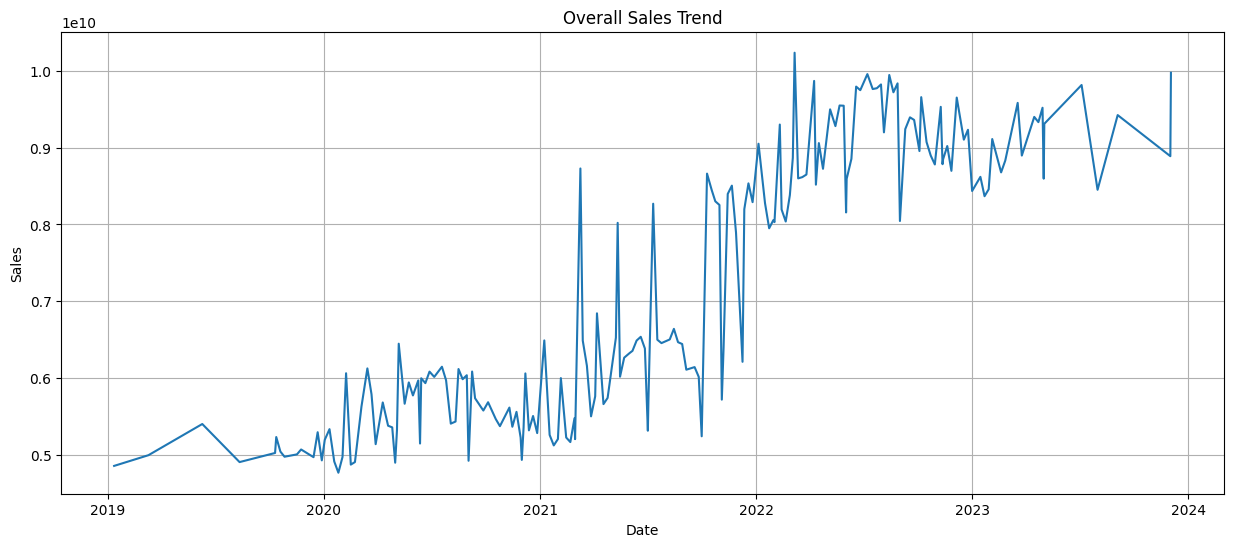

In [5]:
plt.figure(figsize=(15,6))

plt.plot(daily_sales)

plt.title("Overall Sales Trend")

plt.xlabel("Date")

plt.ylabel("Sales")

plt.grid(True)

plt.show()

In [34]:
state_df = df[df['State'] == 'California'].copy()

In [35]:
state_df = state_df.reset_index(drop=True)

Rolling Mean Analysis

In [8]:
state_df['rolling_mean_7'] = (
    state_df['Sales']
    .rolling(window=7)
    .mean()
)

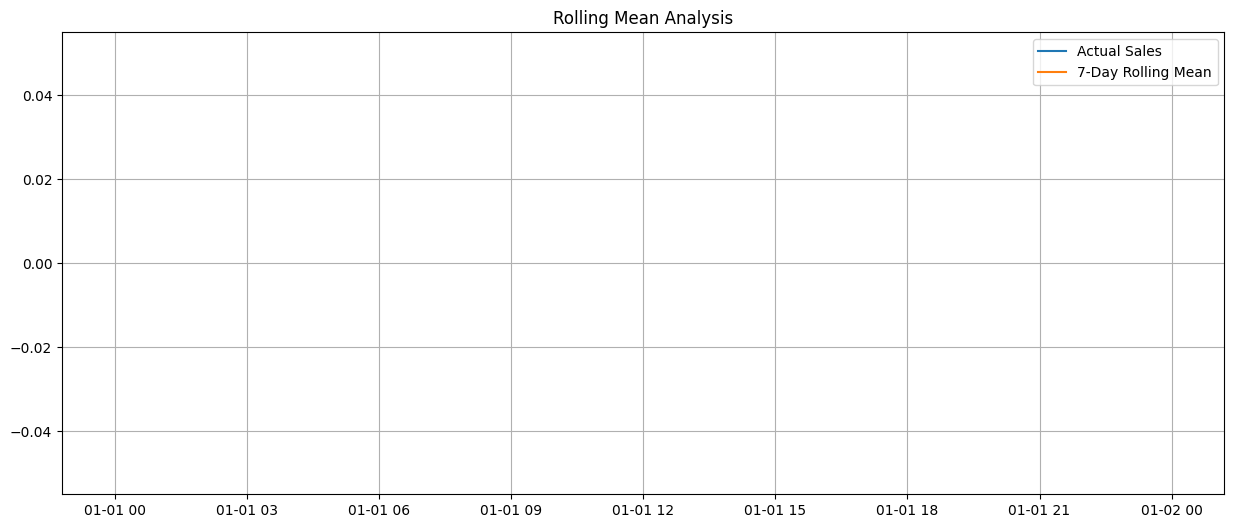

In [9]:
plt.figure(figsize=(15,6))

plt.plot(
    state_df['Date'],
    state_df['Sales'],
    label='Actual Sales'
)

plt.plot(
    state_df['Date'],
    state_df['rolling_mean_7'],
    label='7-Day Rolling Mean'
)

plt.title("Rolling Mean Analysis")

plt.legend()

plt.grid(True)

plt.show()

Monthly Seasonality

In [10]:
df['month'] = df['Date'].dt.month

In [11]:
monthly_sales = df.groupby('month')['Sales'].mean()

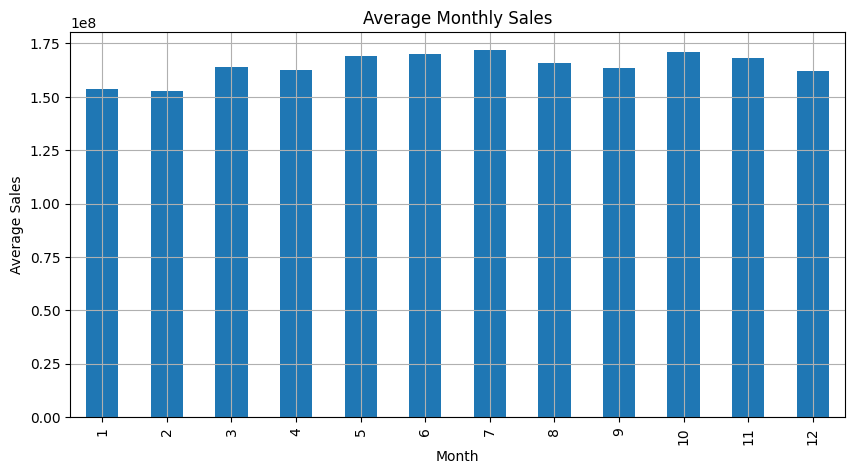

In [12]:
monthly_sales.plot(
    kind='bar',
    figsize=(10,5)
)

plt.title("Average Monthly Sales")

plt.xlabel("Month")

plt.ylabel("Average Sales")

plt.grid(True)

plt.show()

Weekly Pattern Analysis

In [13]:
df['day_of_week'] = df['Date'].dt.day_name()

In [14]:
dow_sales = df.groupby('day_of_week')['Sales'].mean()

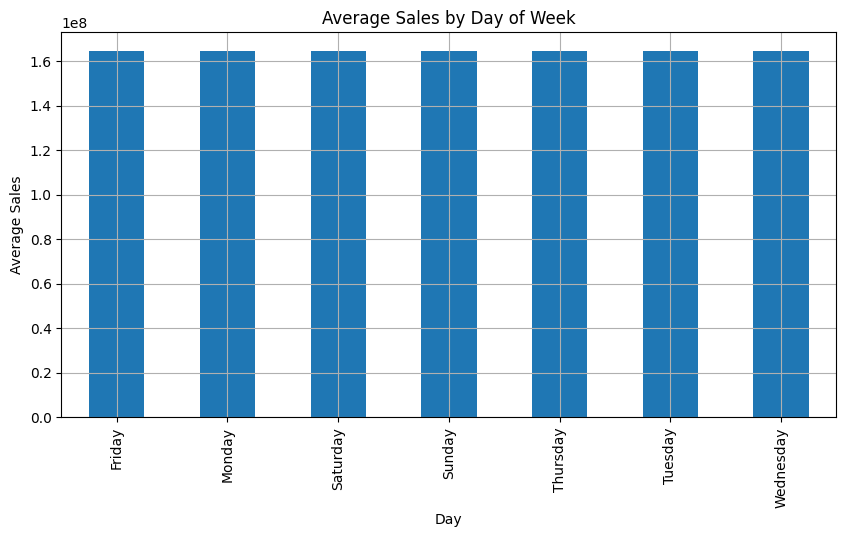

In [15]:
dow_sales.plot(
    kind='bar',
    figsize=(10,5)
)

plt.title("Average Sales by Day of Week")

plt.xlabel("Day")

plt.ylabel("Average Sales")

plt.grid(True)

plt.show()

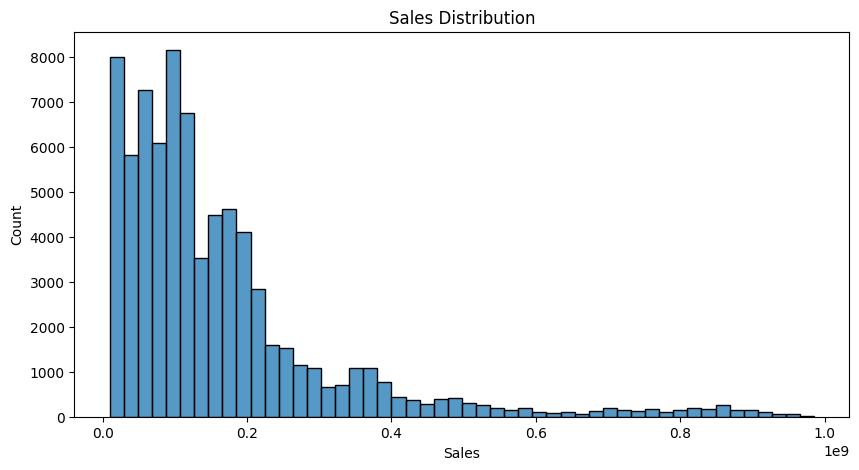

In [16]:
plt.figure(figsize=(10,5))

sns.histplot(df['Sales'], bins=50)

plt.title("Sales Distribution")

plt.show()

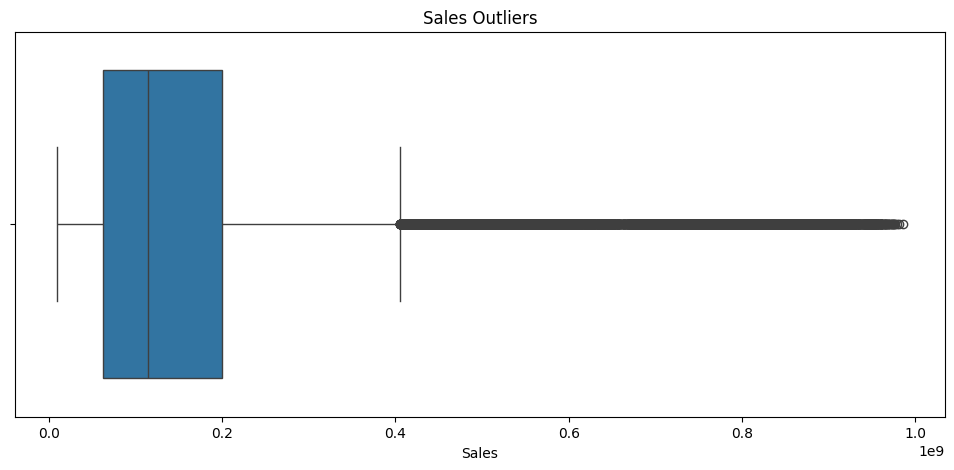

In [17]:
plt.figure(figsize=(12,5))

sns.boxplot(x=df['Sales'])

plt.title("Sales Outliers")

plt.show()

Time Series Decomposition

In [23]:
from statsmodels.tsa.seasonal import seasonal_decompose

In [21]:
print(df['State'].unique())


<StringArray>
[       'Alabama',        'Arizona',       'Arkansas',     'California',
       'Colorado',    'Connecticut',        'Florida',        'Georgia',
       'Illinois',        'Indiana',           'Iowa',         'Kansas',
       'Kentucky',      'Louisiana',          'Maine',       'Maryland',
  'Massachusetts',       'Michigan',      'Minnesota',    'Mississippi',
       'Missouri',       'Nebraska',         'Nevada',  'New Hampshire',
     'New Mexico',       'New York', 'North Carolina',           'Ohio',
       'Oklahoma',         'Oregon',   'Pennsylvania',   'Rhode Island',
 'South Carolina',   'South Dakota',      'Tennessee',          'Texas',
           'Utah',        'Vermont',       'Virginia',     'Washington',
  'West Virginia',      'Wisconsin',        'Wyoming']
Length: 43, dtype: str


In [27]:
state_df = df[df['State'] == 'California'].copy()
print(state_df.shape)

(1787, 7)


In [28]:
print(state_df.head())

           Date       State         Total   Category         Sales  month  \
5361 2019-01-12  California  4.447669e+08  Beverages  4.447669e+08      1   
5362 2019-01-13  California  4.455915e+08        NaN  4.455915e+08      1   
5363 2019-01-14  California  4.464162e+08        NaN  4.464162e+08      1   
5364 2019-01-15  California  4.472409e+08        NaN  4.472409e+08      1   
5365 2019-01-16  California  4.480655e+08        NaN  4.480655e+08      1   

     day_of_week  
5361    Saturday  
5362      Sunday  
5363      Monday  
5364     Tuesday  
5365   Wednesday  


In [29]:
state_df = state_df.set_index('Date')

In [30]:
print(state_df['Sales'].head())

Date
2019-01-12    4.447669e+08
2019-01-13    4.455915e+08
2019-01-14    4.464162e+08
2019-01-15    4.472409e+08
2019-01-16    4.480655e+08
Name: Sales, dtype: float64


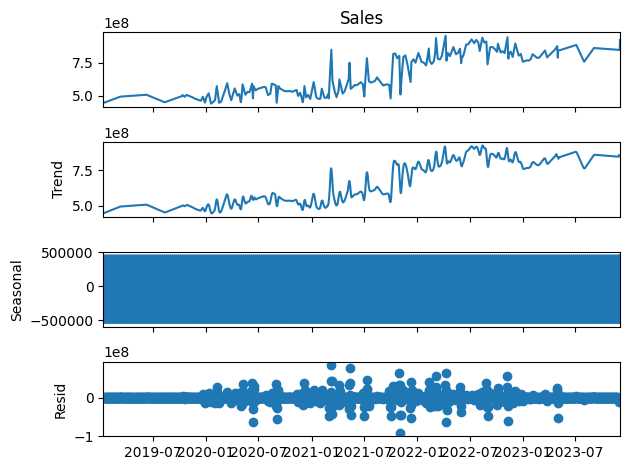

In [31]:
decomposition = seasonal_decompose(
    state_df['Sales'],
    model='additive',
    period=7
)

decomposition.plot()

plt.show()

Correlation Heatmap

In [32]:
numeric_df = df.select_dtypes(include=['number'])

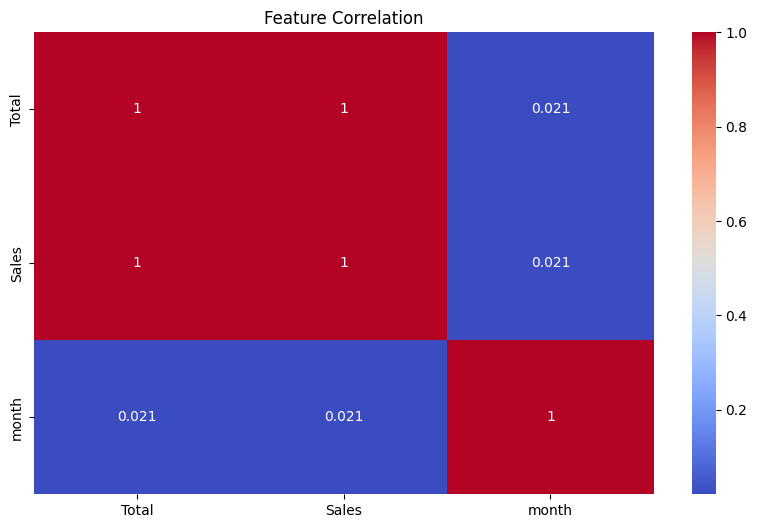

In [33]:
plt.figure(figsize=(10,6))

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap='coolwarm'
)

plt.title("Feature Correlation")

plt.show()